# Gaussian Mixture Models

## Loading and splitting the data

In [1]:
#Student: Oscar Umana
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

# Load the dataset
faces = fetch_olivetti_faces()
X = faces.data 
y = faces.target  

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

## Dimensionality reduction

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)

print("Number of components:", pca.n_components_)

Number of components: 177


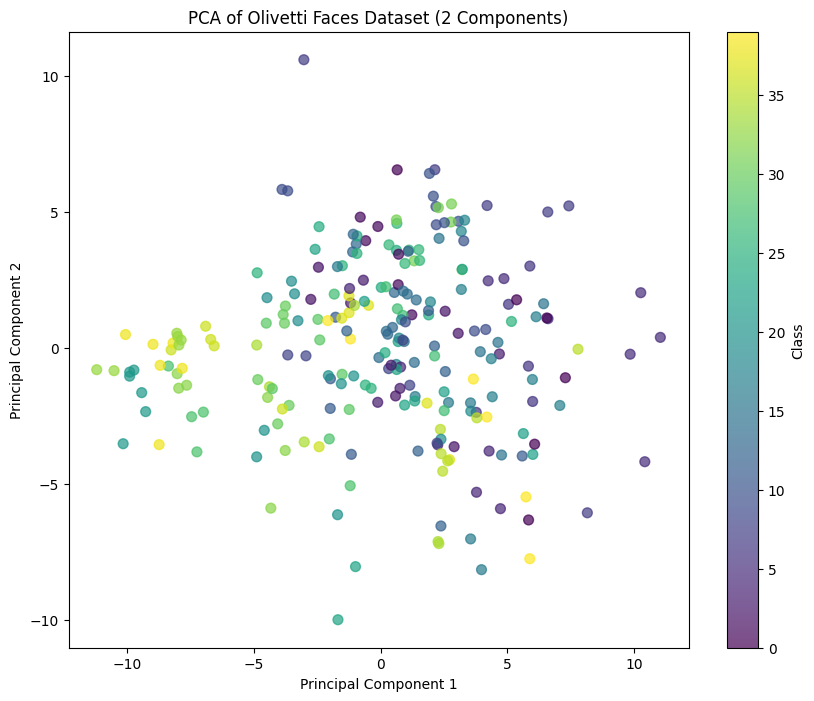

In [28]:
# Reduce to two main components
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train)

# Plot the distribution
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=y_train, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Olivetti Faces Dataset (2 Components)')
plt.show()

## Covariance type

In [3]:
from sklearn.mixture import GaussianMixture

covariance_types = ['full', 'tied', 'diag', 'spherical']
best_aic = float('inf')
best_cov_type = None

for cov_type in covariance_types:
    gmm = GaussianMixture(n_components=10, covariance_type=cov_type)
    gmm.fit(X_train_pca)
    if gmm.aic(X_train_pca) < best_aic:
        best_aic = gmm.aic(X_train_pca)
        best_cov_type = cov_type

print('Best covariance type:', best_cov_type)

Best covariance type: full


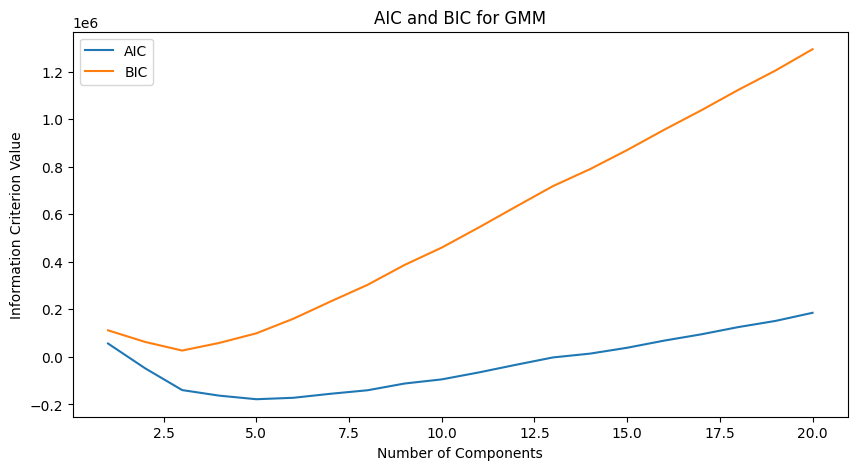

In [4]:
import matplotlib.pyplot as plt

n_components_range = range(1, 21)
aic_values = []
bic_values = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type=best_cov_type)
    gmm.fit(X_train_pca)
    aic_values.append(gmm.aic(X_train_pca))
    bic_values.append(gmm.bic(X_train_pca))

# Find optimal number of clusters
optimal_n_clusters_aic = n_components_range[aic_values.index(min(aic_values))]
optimal_n_clusters_bic = n_components_range[bic_values.index(min(bic_values))]

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, aic_values, label='AIC')
plt.plot(n_components_range, bic_values, label='BIC')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion Value')
plt.title('AIC and BIC for GMM')
plt.legend()
plt.show()

In [6]:
print('Optimal number of clusters (AIC):', optimal_n_clusters_aic)

Optimal number of clusters (AIC): 5


In [26]:
gmm = GaussianMixture(n_components=optimal_n_clusters_aic, covariance_type=best_cov_type)
gmm.fit(X_train_pca)
hard_assignments = gmm.predict(X_train_pca)

soft_assignments = gmm.predict_proba(X_train_pca)

print('Hard Assignments:', hard_assignments[:10])
print('Real Labels:', y_train[:10])

print('Soft Assignments:', soft_assignments[:10])

Hard Assignments: [1 0 0 1 3 0 0 4 1 4]
Real Labels: [ 4  2 24  4 17 29 13 32  4 33]
Soft Assignments: [[0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


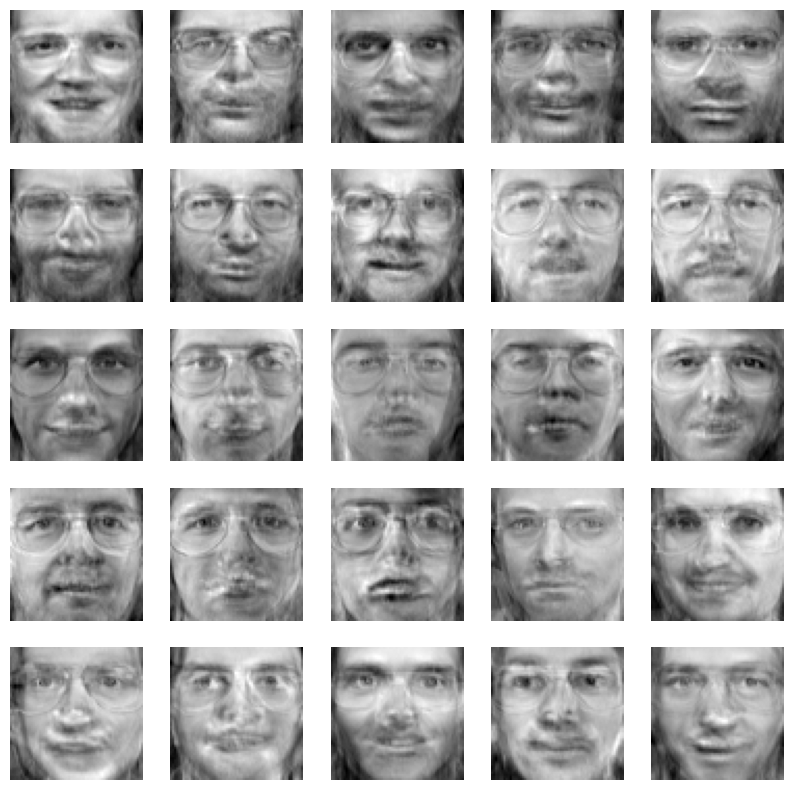

In [10]:
n = 5
generated_faces = gmm.sample(n * n)[0]
# Inverse transform to original space
new_faces = pca.inverse_transform(generated_faces)

# Visualization
plt.figure(figsize=(10, 10))
for i, face in enumerate(new_faces):
    plt.subplot(n, n, i + 1)
    plt.imshow(face.reshape(64, 64), cmap='gray')
    plt.axis('off')
plt.show()

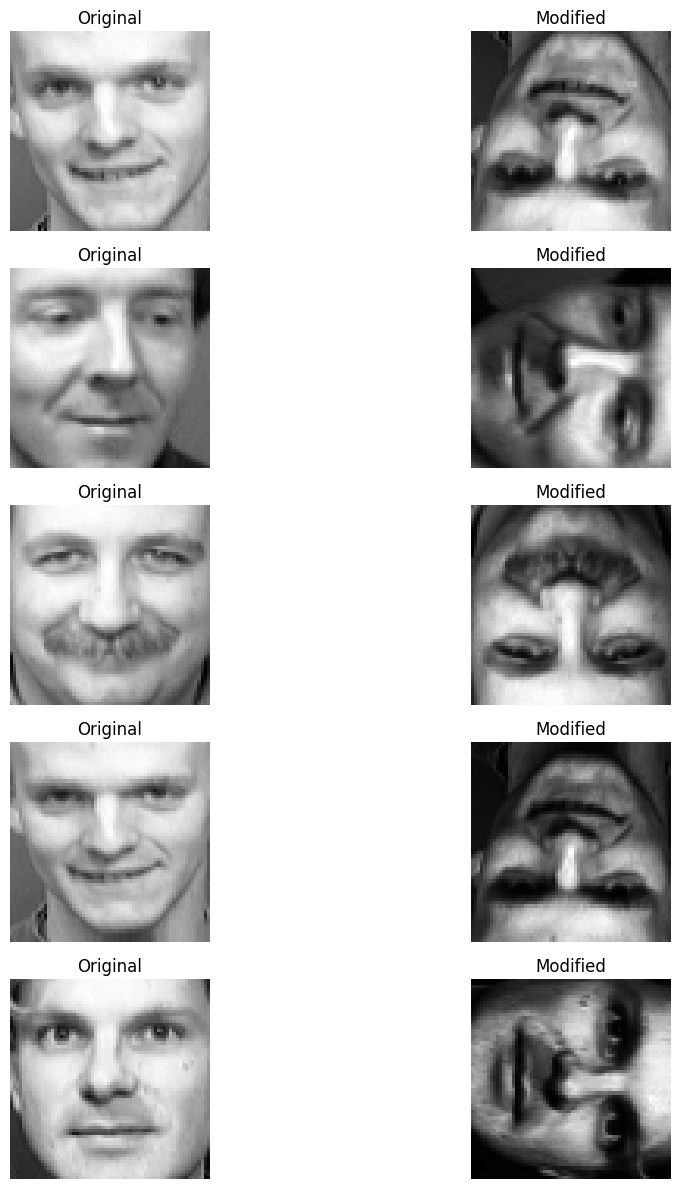

In [23]:
from skimage.transform import rotate
from skimage import exposure
import numpy as np

#function that takes an image and returns a modified version of it
def modify_image(image):
    image = image.reshape(64, 64)
    # Rotate the image 
    angles = [90, 180, 270]
    angle = np.random.choice(angles)
    image = rotate(image, angle=angle)
    
    # Flip the image horizontally
    image = image[:, ::-1]
    
    # Darken the image
    gamma_value = np.random.uniform(2, 5)
    image = exposure.adjust_gamma(image, gamma=gamma_value)
    
    return image

# Select a few images to modify
modified_faces = [modify_image(face) for face in X_train[:5]]

# Create a figure to display the original and modified images
fig, axes = plt.subplots(5, 2, figsize=(12, 12))

for i, face in enumerate(modified_faces):
    # Original image
    axes[i, 0].imshow(X_train[i].reshape(64, 64), cmap='gray')
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    # Modified image
    axes[i, 1].imshow(face, cmap='gray')
    axes[i, 1].set_title('Modified')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Score the normal images
normal_scores = gmm.score_samples(X_train_pca[:5])

# Score the modified images
modified_faces_pca = pca.transform(np.array(modified_faces).reshape(len(modified_faces), -1))
anomaly_scores = gmm.score_samples(modified_faces_pca)

# Compare the scores
for i in range(len(normal_scores)):
    print(f"Normal image {i+1} score: {normal_scores[i]}, Anomalous image {i+1} score: {anomaly_scores[i]}")

Normal image 1 score: 731.9261956752384, Anomalous image 1 score: -25912186.38446402
Normal image 2 score: 594.9347294348179, Anomalous image 2 score: -35288897.87134732
Normal image 3 score: 594.9349189917621, Anomalous image 3 score: -28548157.430006165
Normal image 4 score: 884.9837113012353, Anomalous image 4 score: -40559464.414099336
Normal image 5 score: 731.926363901633, Anomalous image 5 score: -42379505.95379907
